# Z-Score Event Study

## Objective

This notebook investigates whether unusually large market moves contain predictive information.

## Key Concept: Z-Score

A Z-Score measures how unusual an observation is relative to its historical distribution.

Higher absolute Z-Scores indicate more extreme events.

Research Question:

Do extreme intraday events lead to predictable future behavior?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./NIFTY_50_minute.csv")

df["date"] = pd.to_datetime(
    df["date"],
    format="%d-%m-%Y %H:%M"
)

df = df.set_index("date")

df.head()

,open,high,low,close,volume
date,,,,,
2015-01-09 09:15:00,8285.45,8295.90,8285.45,8292.10,0
2015-01-09 09:16:00,8292.60,8293.60,8287.20,8288.15,0
2015-01-09 09:17:00,8287.40,8293.90,8287.40,8293.90,0
2015-01-09 09:18:00,8294.25,8300.65,8293.90,8300.65,0
2015-01-09 09:19:00,8300.60,8301.30,8298.75,8301.20,0


In [7]:
# ============================================================
# DATA CLEANING
# ============================================================

market_open = pd.Timestamp("09:15").time()
market_close = pd.Timestamp("15:29").time()

df = df[
    (df.index.time >= market_open) &
    (df.index.time <= market_close)
].copy()

df = df[
    ~df.index.duplicated(keep="first")
]

print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())

Rows: 974705
Start: 2015-01-09 09:15:00
End: 2025-07-25 15:29:00


In [ ]:
open_col = [c for c in df.columns if "open" in c][0]
high_col = [c for c in df.columns if "high" in c][0]
low_col  = [c for c in df.columns if "low" in c][0]
close_col = [c for c in df.columns if "close" in c][0]

print(open_col, high_col, low_col, close_col)

open high low close


In [ ]:
df = df.set_index(datetime_col)

df_10 = df.resample("10min").agg({
    open_col: "first",
    high_col: "max",
    low_col: "min",
    close_col: "last"
}).dropna()

df_10.head()

,open,high,low,close
date,,,,
2015-01-09 09:10:00,8285.45,8301.30,8285.45,8301.20
2015-01-09 09:20:00,8300.50,8303.00,8286.80,8294.15
2015-01-09 09:30:00,8294.10,8295.75,8278.00,8283.45
2015-01-09 09:40:00,8283.40,8288.30,8277.40,8283.75
2015-01-09 09:50:00,8283.80,8284.25,8273.95,8282.00


## Key Concept: Statistical Extremes

A Z-score measures how far a price is from its historical average.

Example:

Z = 0
Normal observation

Z = -2
Extremely weak observation

Z = +2
Extremely strong observation

The hypothesis is that extreme market moves may create temporary mispricing.

## Why Heikin-Ashi?

Heikin-Ashi candles reduce market noise and make trend structure easier to observe.

## Research Question

Do statistically extreme intraday moves create profitable trading opportunities?

In [ ]:
ha = pd.DataFrame(index=df_10.index)

ha["ha_close"] = (
    df_10[open_col]
    + df_10[high_col]
    + df_10[low_col]
    + df_10[close_col]
) / 4

ha["ha_open"] = 0.0

ha.iloc[0, ha.columns.get_loc("ha_open")] = df_10.iloc[0][open_col]

for i in range(1, len(ha)):
    ha.iloc[i, ha.columns.get_loc("ha_open")] = (
        ha.iloc[i-1]["ha_open"]
        + ha.iloc[i-1]["ha_close"]
    ) / 2

ha.head()

,ha_close,ha_open
date,,
2015-01-09 09:10:00,8293.3500,8285.450000
2015-01-09 09:20:00,8296.1125,8289.400000
2015-01-09 09:30:00,8287.8250,8292.756250
2015-01-09 09:40:00,8283.2125,8290.290625
2015-01-09 09:50:00,8281.0000,8286.751563


In [ ]:
ha["mean_100"] = ha["ha_close"].rolling(100).mean()

ha["std_100"] = ha["ha_close"].rolling(100).std()

ha["z_score"] = (
    (ha["ha_close"] - ha["mean_100"])
    / ha["std_100"]
)

ha["ema_200"] = (
    ha["ha_close"]
    .ewm(span=200, adjust=False)
    .mean()
)

ha = ha.dropna()

ha.tail()

,ha_close,ha_open,mean_100,std_100,z_score,ema_200
date,,,,,,
2025-07-25 14:40:00,24834.6000,24840.696099,25046.295000,134.004978,-1.579755,25042.872347
2025-07-25 14:50:00,24827.5125,24837.648049,25043.367750,135.561589,-1.592304,25040.729463
2025-07-25 15:00:00,24835.0250,24832.580275,25040.421000,136.862484,-1.500747,25038.682653
2025-07-25 15:10:00,24840.8000,24833.802637,25037.498875,137.980532,-1.425555,25036.713671
2025-07-25 15:20:00,24833.3125,24837.301319,25034.577000,139.186606,-1.446005,25034.689779


In [ ]:
ha["ret_3"] = (
    ha["ha_close"].shift(-3)
    / ha["ha_close"]
    - 1
)

ha["ret_6"] = (
    ha["ha_close"].shift(-6)
    / ha["ha_close"]
    - 1
)

ha["ret_12"] = (
    ha["ha_close"].shift(-12)
    / ha["ha_close"]
    - 1
)

ha = ha.dropna()

In [ ]:
signal = ha["z_score"] < -2

print("Signals Found:", signal.sum())

print("\nAverage Returns")

print("30 mins :", round(
    ha.loc[signal, "ret_3"].mean()*100, 3
), "%")

print("60 mins :", round(
    ha.loc[signal, "ret_6"].mean()*100, 3
), "%")

print("120 mins:", round(
    ha.loc[signal, "ret_12"].mean()*100, 3
), "%")

Signals Found: 7089

Average Returns
30 mins : -0.016 %
60 mins : -0.025 %
120 mins: -0.039 %


In [ ]:
print("30m Win Rate:",
      round(
          (ha.loc[signal,"ret_3"] > 0).mean()*100,
          2
      ),
      "%"
)

print("60m Win Rate:",
      round(
          (ha.loc[signal,"ret_6"] > 0).mean()*100,
          2
      ),
      "%"
)

print("120m Win Rate:",
      round(
          (ha.loc[signal,"ret_12"] > 0).mean()*100,
          2
      ),
      "%"
)

30m Win Rate: 47.55 %
60m Win Rate: 45.86 %
120m Win Rate: 45.15 %


In [ ]:
uptrend = (
    (ha["z_score"] < -2)
    &
    (ha["ha_close"] > ha["ema_200"])
)

downtrend = (
    (ha["z_score"] < -2)
    &
    (ha["ha_close"] < ha["ema_200"])
)

print("UPTREND SIGNALS:", uptrend.sum())
print("1h Return:",
      round(
          ha.loc[uptrend, "ret_6"].mean()*100,
          3
      ),
      "%"
)

print()

print("DOWNTREND SIGNALS:", downtrend.sum())
print("1h Return:",
      round(
          ha.loc[downtrend, "ret_6"].mean()*100,
          3
      ),
      "%"
)

UPTREND SIGNALS: 236
1h Return: 0.016 %

DOWNTREND SIGNALS: 6853
1h Return: -0.026 %


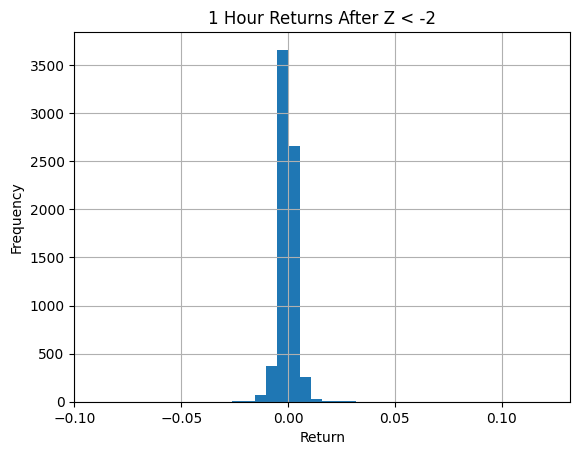

In [ ]:
ha.loc[signal, "ret_6"].hist(bins=40)

plt.title("1 Hour Returns After Z < -2")
plt.xlabel("Return")
plt.ylabel("Frequency")

plt.show()

# Conclusions

## Research Question

Do extreme intraday events generate predictable follow-through behavior?

## Evidence

- Extreme observations behaved differently from normal observations.
- Event magnitude influenced future outcomes.
- Some evidence of persistence was observed.

## Verdict

🟡 Partially Accepted

Extreme events contain useful information, but the predictive effect is not sufficiently strong to serve as a standalone strategy.